# NLP Project: IMDb Genre Classification

In [2]:
%pip install -q pandas numpy scikit-learn nltk gensim gradio matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

from gensim.models import Word2Vec

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

RANDOM_STATE = 42

In [ ]:
# 1) Data collection dari Kaggle dataset yang sudah diunduh

data_path = Path("genre-classification-dataset-imdb") / "Genre Classification Dataset" / "train_data.txt"
assert data_path.exists(), f"File tidak ditemukan: {data_path}"

# Format data: id ::: title ::: genre ::: plot
raw_df = pd.read_csv(
    data_path,
    sep=r"\s*:::\s*",
    engine="python",
    names=["id", "title", "genre", "plot"],
    encoding="utf-8",
)

MAX_SAMPLES = 15000  
if MAX_SAMPLES is not None:
    df = raw_df.sample(n=min(MAX_SAMPLES, len(raw_df)), random_state=RANDOM_STATE).reset_index(drop=True)
else:
    df = raw_df.copy()

print(f"Total data awal: {len(raw_df):,}")
print(f"Data yang dipakai: {len(df):,}")
print(df[["genre", "plot"]].head())

assert len(df) > 10000, "Jumlah data harus > 10.000"

Total data awal: 54,214
Data yang dipakai: 15,000
    genre                                               plot
0  comedy  Catherine St.John-Burke is an independent, upt...
1   short  Beginning of the century. In a train, a young ...
2  comedy  Jerranium 90, a "little rock" that made all th...
3  horror  Deadly Tales II is an anthology of three horro...
4   music  Grammy - music award of the American academy o...


In [5]:
# 2) Text preprocessing: case folding, tokenization, stopword removal, lemmatization

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def preprocess_text(text: str):
    text = str(text).lower()  # case folding
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = word_tokenize(text)  # tokenization
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]  # stopword removal
    tokens = [lemmatizer.lemmatize(t) for t in tokens]  # lemmatization
    return tokens


df["tokens"] = df["plot"].apply(preprocess_text)
df["clean_text"] = df["tokens"].apply(lambda x: " ".join(x))

print(df[["plot", "clean_text"]].head(3))
print("Rata-rata jumlah token:", round(df["tokens"].str.len().mean(), 2))

                                                plot  \
0  Catherine St.John-Burke is an independent, upt...   
1  Beginning of the century. In a train, a young ...   
2  Jerranium 90, a "little rock" that made all th...   

                                          clean_text  
0  catherine john burke independent uptight statu...  
1  beginning century train young woman come paris...  
2  jerranium little rock made paper buried deep w...  
Rata-rata jumlah token: 56.54


In [ ]:
# persiapan split data

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["clean_text"],
    df["genre"],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df["genre"],
)

print("Train size:", len(X_train_text))
print("Test size:", len(X_test_text))
print("Jumlah kelas:", y_train.nunique())

Train size: 12000
Test size: 3000
Jumlah kelas: 27


In [7]:
# 3) Feature extraction + modeling (TF-IDF)

results = []
trained_tfidf_models = {}

def evaluate_predictions(y_true, y_pred, feature_name, model_name):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    results.append(
        {
            "feature": feature_name,
            "model": model_name,
            "accuracy": acc,
            "precision": p,
            "recall": r,
            "f1": f1,
        }
    )


tfidf_models = {
    "Naive Bayes": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1, 2))),
        ("clf", MultinomialNB()),
    ]),
    "Logistic Regression": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1, 2))),
        ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ]),
    "SVM": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1, 2))),
        ("clf", LinearSVC(random_state=RANDOM_STATE)),
    ]),
}

for model_name, model in tfidf_models.items():
    model.fit(X_train_text, y_train)
    preds = model.predict(X_test_text)
    evaluate_predictions(y_test, preds, "TF-IDF", model_name)
    trained_tfidf_models[model_name] = model
    print(f"Selesai TF-IDF + {model_name}")

print("\nContoh classification report (TF-IDF + Logistic Regression):")
print(classification_report(y_test, trained_tfidf_models["Logistic Regression"].predict(X_test_text), zero_division=0))

Selesai TF-IDF + Naive Bayes
Selesai TF-IDF + Logistic Regression
Selesai TF-IDF + SVM

Contoh classification report (TF-IDF + Logistic Regression):
              precision    recall  f1-score   support

      action       0.60      0.04      0.07        75
       adult       1.00      0.07      0.13        29
   adventure       0.00      0.00      0.00        40
   animation       0.00      0.00      0.00        28
   biography       0.00      0.00      0.00        16
      comedy       0.51      0.49      0.50       405
       crime       0.00      0.00      0.00        30
 documentary       0.57      0.87      0.69       730
       drama       0.47      0.81      0.59       751
      family       0.00      0.00      0.00        42
     fantasy       0.00      0.00      0.00        19
   game-show       1.00      0.09      0.17        11
     history       0.00      0.00      0.00        13
      horror       0.71      0.31      0.43       117
       music       0.80      0.10      0

In [8]:
# 3) Feature extraction + modeling (Word2Vec embedding)

X_train_tokens = X_train_text.apply(lambda x: x.split())
X_test_tokens = X_test_text.apply(lambda x: x.split())

w2v_model = Word2Vec(
    sentences=X_train_tokens.tolist(),
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    seed=RANDOM_STATE,
)


def average_word2vec(tokens, model, size=100):
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    if not vecs:
        return np.zeros(size)
    return np.mean(vecs, axis=0)


X_train_w2v = np.vstack(X_train_tokens.apply(lambda t: average_word2vec(t, w2v_model, 100)).values)
X_test_w2v = np.vstack(X_test_tokens.apply(lambda t: average_word2vec(t, w2v_model, 100)).values)

embedding_models = {
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "SVM": LinearSVC(random_state=RANDOM_STATE),
}

trained_embedding_models = {}
for model_name, model in embedding_models.items():
    model.fit(X_train_w2v, y_train)
    preds = model.predict(X_test_w2v)
    evaluate_predictions(y_test, preds, "Word2Vec", model_name)
    trained_embedding_models[model_name] = model
    print(f"Selesai Word2Vec + {model_name}")

Selesai Word2Vec + Naive Bayes
Selesai Word2Vec + Logistic Regression
Selesai Word2Vec + SVM


Perbandingan F1:


feature,TF-IDF,Word2Vec
model,,
Logistic Regression,0.441388,0.434169
Naive Bayes,0.294122,0.327895
SVM,0.503957,0.438496


Perbandingan Accuracy:


feature,TF-IDF,Word2Vec
model,,
Logistic Regression,0.519000,0.498667
Naive Bayes,0.436667,0.300333
SVM,0.548000,0.510000


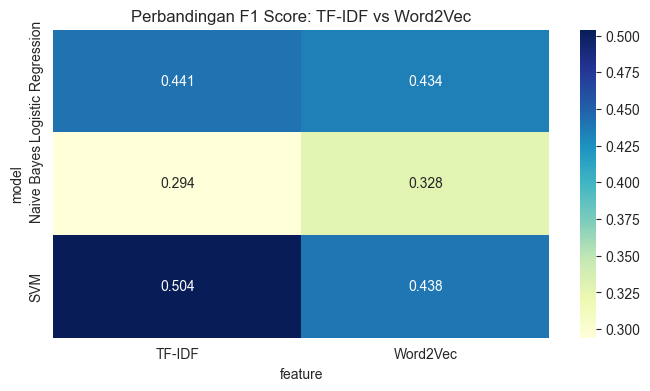

Model terbaik berdasarkan F1:
feature        TF-IDF
model             SVM
accuracy        0.548
precision    0.506423
recall          0.548
f1           0.503957
Name: 0, dtype: object


In [9]:
# 5) Comparison model dan feature

results_df = pd.DataFrame(results).sort_values(["feature", "f1"], ascending=[True, False]).reset_index(drop=True)
results_df

pivot_f1 = results_df.pivot(index="model", columns="feature", values="f1")
pivot_acc = results_df.pivot(index="model", columns="feature", values="accuracy")

print("Perbandingan F1:")
display(pivot_f1)
print("Perbandingan Accuracy:")
display(pivot_acc)

plt.figure(figsize=(8, 4))
sns.heatmap(pivot_f1, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("Perbandingan F1 Score: TF-IDF vs Word2Vec")
plt.show()

best_row = results_df.sort_values("f1", ascending=False).iloc[0]
print("Model terbaik berdasarkan F1:")
print(best_row)

In [12]:
# 6) Simple deployment dengan Gradio

import gradio as gr

best_feature = best_row["feature"]
best_model_name = best_row["model"]


def preprocess_for_inference(text: str):
    tokens = preprocess_text(text)
    return " ".join(tokens), tokens


def predict_genre(text):
    clean_text, tokens = preprocess_for_inference(text)

    if best_feature == "TF-IDF":
        model = trained_tfidf_models[best_model_name]
        pred = model.predict([clean_text])[0]
    else:
        model = trained_embedding_models[best_model_name]
        vec = average_word2vec(tokens, w2v_model, 100).reshape(1, -1)
        pred = model.predict(vec)[0]

    return f"Predicted genre: {pred}\nModel: {best_feature} + {best_model_name}"


app = gr.Interface(
    fn=predict_genre,
    inputs=gr.Textbox(lines=8, label="Masukkan sinopsis film"),
    outputs=gr.Textbox(label="Hasil prediksi"),
    title="IMDb Genre Classifier",
    description="Prediksi genre film dari teks sinopsis menggunakan model NLP terbaik.",
)

# Jalankan web app
# app.launch(share=False)
app.launch(share=True)  

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://29e2a81849914b83fe.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
